# SBND voxel flux plots

This notebook loads the merged voxel flux pkls produced by
[`build_voxel_flux.py`](build_voxel_flux.py) and makes the SBND plots.

**Make the pkls first**:

```bash
python build_voxel_flux.py --help
python build_voxel_flux.py
```

This writes `full_voxel_flux_potmacro.pkl` under `--cache-dir` (default
`/exp/sbnd/data/users/munjung/flux/SBND_dk2nu`).

Jobs are merged in the build script with **POT-weighted** averages using
`/run/beamOn` from each job's `production*.in` next to the hist ROOT files.


In [1]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    plt.style.use("../numucc_1p0pi/presentation.mplstyle")
except OSError:
    pass


## Load flux files


In [2]:
# flux summary file
FULL_FLUX_PATH = Path("/exp/sbnd/data/users/munjung/flux/SBND_dk2nu/full_voxel_flux_potmacro.pkl")
with open(FULL_FLUX_PATH, "rb") as f:
    data = pickle.load(f)


# binnings
flux_voxel = data["flux"]
bin_edges = np.asarray(data["bin_edges"])
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
Z_EDGES = np.asarray(data["z_edges"])
Y_EDGES = np.asarray(data["y_edges"])
X_EDGES = np.asarray(data["x_edges"])
Z_LO = Z_EDGES[:-1]

NZ = Z_EDGES.size - 1
NY = Y_EDGES.size - 1
NX = X_EDGES.size - 1

VOXEL_SIZE = int(data.get("voxel_size", int(round(X_EDGES[1] - X_EDGES[0]))))
VOXEL_AREA_M2 = float(data.get("voxel_area_m2", (VOXEL_SIZE * 1e-2) ** 2))

# nu flavors
FLAVORS = list(data["flavors"])
FLAVOR_LATEX = {
    "nue":     r"$\nu_e$",
    "nuebar":  r"$\bar{\nu}_e$",
    "numu":    r"$\nu_\mu$",
    "numubar": r"$\bar{\nu}_\mu$",
}

print("Loaded", FULL_FLUX_PATH)
print("flux shape (NZ, NY, NX, n_flav, n_E):", flux_voxel.shape)
print("voxel_size_cm:", VOXEL_SIZE, "  voxel_area_m2:", VOXEL_AREA_M2)

Loaded /exp/sbnd/data/users/munjung/flux/SBND_dk2nu/full_voxel_flux_potmacro.pkl
flux shape (NZ, NY, NX, n_flav, n_E): (25, 20, 20, 4, 200)
voxel_size_cm: 20   voxel_area_m2: 0.04000000000000001


In [3]:
# pot_per_zy = data.get("pot_per_zy")
# if pot_per_zy is not None and (pot_per_zy > 0).any():
#     print("POT per (z,y) slice: min", float(pot_per_zy[pot_per_zy > 0].min()), "max", float(pot_per_zy.max()))

## Plot helpers

Per-voxel histograms are already flux per POT from `beamHistVoxel`.  Summing
selected voxels and dividing by `N_voxels * VOXEL_AREA_M2` gives the average
flux density in $\mathrm{m}^{-2}\,\mathrm{POT}^{-1}$ per energy bin.


In [4]:
def voxel_mask(x_range=None, y_range=None, z_range=None,
               x_pred=None, y_pred=None, z_pred=None):
    # function to select voxels
    z_keep = np.ones(NZ, bool)
    y_keep = np.ones(NY, bool)
    x_keep = np.ones(NX, bool)
    if z_range is not None:
        z_keep &= (Z_EDGES[:-1] >= z_range[0]) & (Z_EDGES[:-1] < z_range[1])
    if y_range is not None:
        y_keep &= (Y_EDGES[:-1] >= y_range[0]) & (Y_EDGES[:-1] < y_range[1])
    if x_range is not None:
        x_keep &= (X_EDGES[:-1] >= x_range[0]) & (X_EDGES[:-1] < x_range[1])
    if z_pred is not None:
        z_keep &= z_pred(Z_EDGES[:-1])
    if y_pred is not None:
        y_keep &= y_pred(Y_EDGES[:-1])
    if x_pred is not None:
        x_keep &= x_pred(X_EDGES[:-1])
    return z_keep[:, None, None] & y_keep[None, :, None] & x_keep[None, None, :]


def flux_for_volume(mask, flavor, source=flux_voxel):
    #  / m^2 / POT
    fi = FLAVORS.index(flavor)
    sub = source[..., fi, :][mask]
    n_voxels = sub.shape[0]
    if n_voxels == 0:
        return np.zeros(source.shape[-1]), 0
    return sub.sum(axis=0) / (n_voxels * VOXEL_AREA_M2), n_voxels


def integrated_flux(spectrum):
    return spectrum.sum()

## Total flux for the SBND detector volume

FV: `z in [11000, 11500] cm`, `y in [-200, 200] cm`, `x in [-200, 200] cm`.


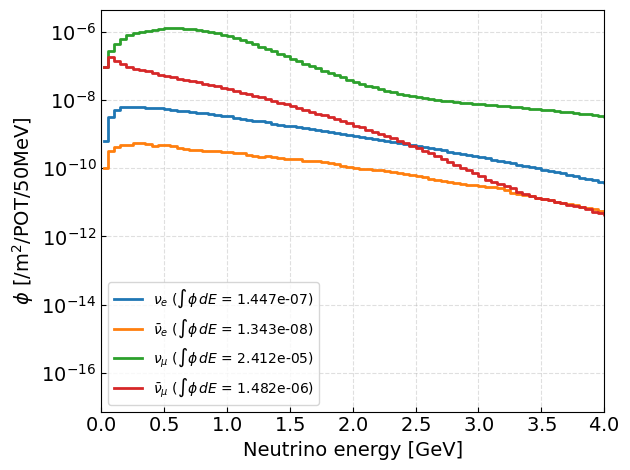

In [5]:
SBND_VOLUME = dict(z_range=(11000, 11500), y_range=(-200, 200), x_range=(-200, 200))

sbnd_mask = voxel_mask(**SBND_VOLUME)

fig, ax = plt.subplots()
sbnd_volume_spectra = {}
for flav in FLAVORS:
    spectrum, n_vox = flux_for_volume(sbnd_mask, flav)
    sbnd_volume_spectra[flav] = spectrum
    integ = integrated_flux(spectrum)
    ax.step(
        bin_centers, spectrum, where="mid",
        label=f"{FLAVOR_LATEX[flav]} ($\\int\\phi\\,dE$ = {integ:.3e})",
    )

ax.set_xlim(0, 4)
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.show()


## Flux through the flux window at different `z`

The flux window is `x, y in [-200, 200]` for one 20 cm `z` slab at a time.


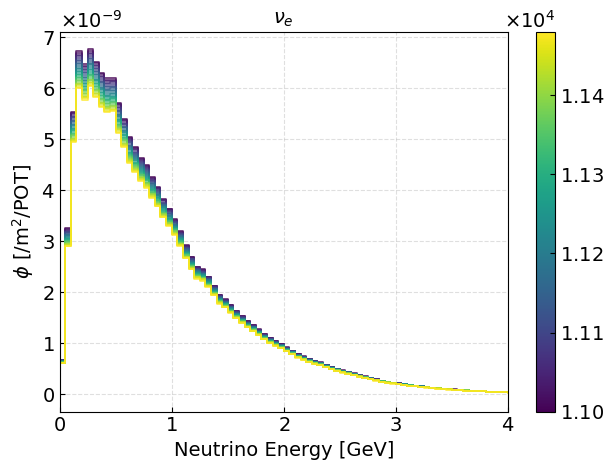

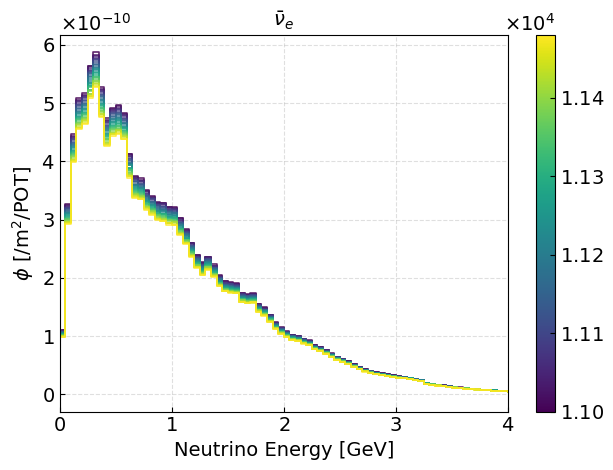

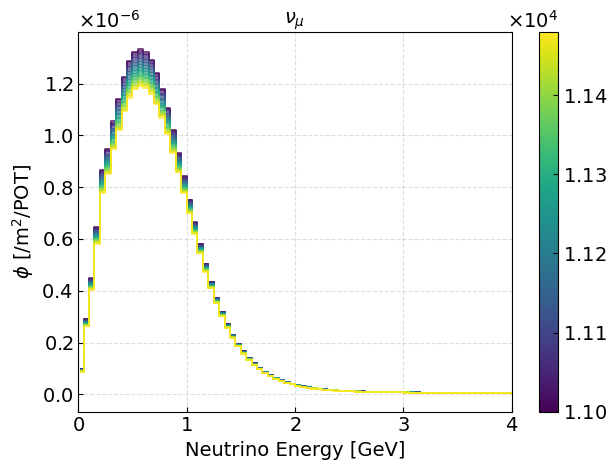

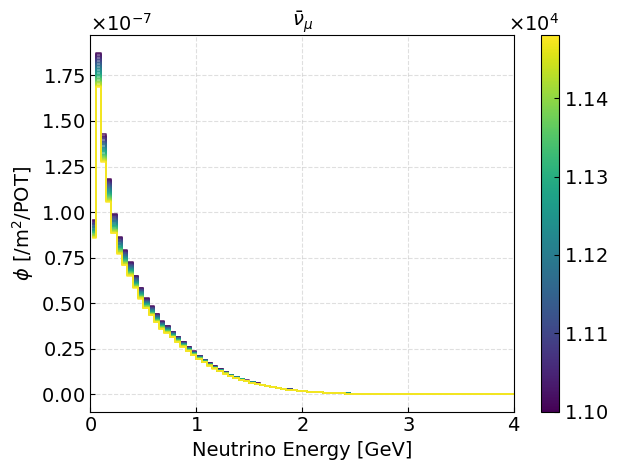

In [6]:
FLUX_WINDOW_XY = dict(x_range=(-200, 200), y_range=(-200, 200))

z_slabs = list(Z_LO[Z_LO < 11500])
z_slab_spectra = {flav: np.zeros((len(z_slabs), len(bin_centers))) for flav in FLAVORS}
z_slab_integ = {flav: np.zeros(len(z_slabs)) for flav in FLAVORS}

for iz, z in enumerate(z_slabs):
    mask_z = voxel_mask(z_range=(z, z + VOXEL_SIZE), **FLUX_WINDOW_XY)
    for flav in FLAVORS:
        spec, _ = flux_for_volume(mask_z, flav)
        z_slab_spectra[flav][iz] = spec
        z_slab_integ[flav][iz] = integrated_flux(spec)

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=z_slabs[0], vmax=z_slabs[-1])
for flav in FLAVORS:
    fig, ax = plt.subplots()
    for iz, z in enumerate(z_slabs):
        ax.step(bin_centers, z_slab_spectra[flav][iz], where="mid",
                color=cmap(norm(z)), alpha=0.85, linewidth=1.2, label=f"z={z:.0f}")
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino Energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]}")
    ax.grid(True, alpha=0.4)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax)
    plt.tight_layout()
    # plt.legend()
    plt.show()

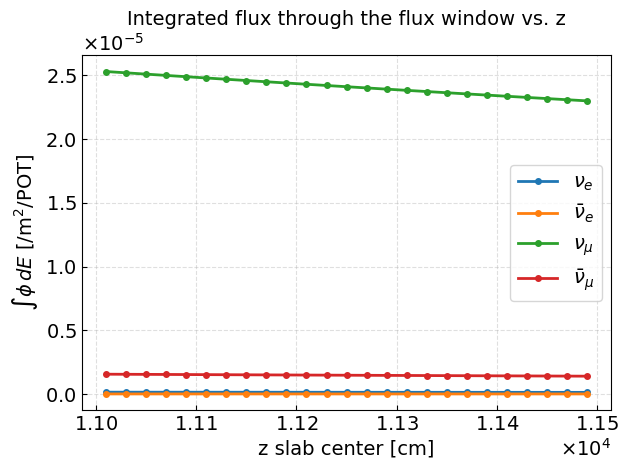

In [7]:
fig, ax = plt.subplots()
for flav in FLAVORS:
    ax.plot(np.array(z_slabs) + VOXEL_SIZE / 2, z_slab_integ[flav],
            marker="o", markersize=4, label=FLAVOR_LATEX[flav])
ax.set_xlabel("z slab center [cm]")
ax.set_ylabel(r"$\int \phi\,dE$ [/m$^2$/POT]")
ax.set_title("Integrated flux through the flux window vs. z")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Flux at the detector face for different `(x, y)` windows

Upstream face `z in [11000, 11020]`.


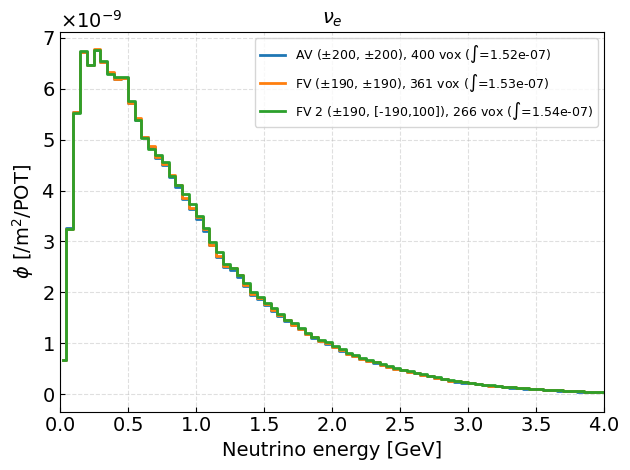

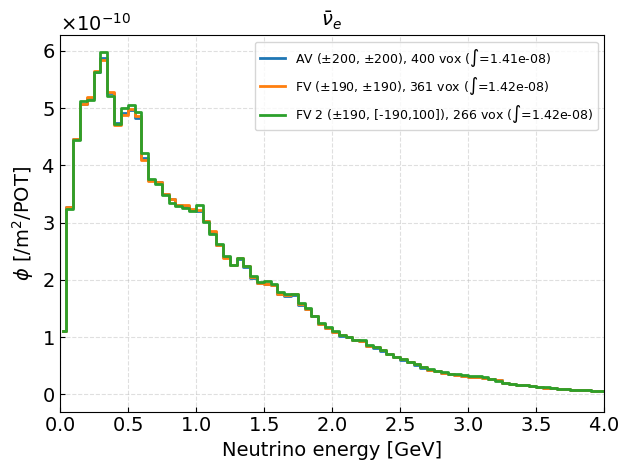

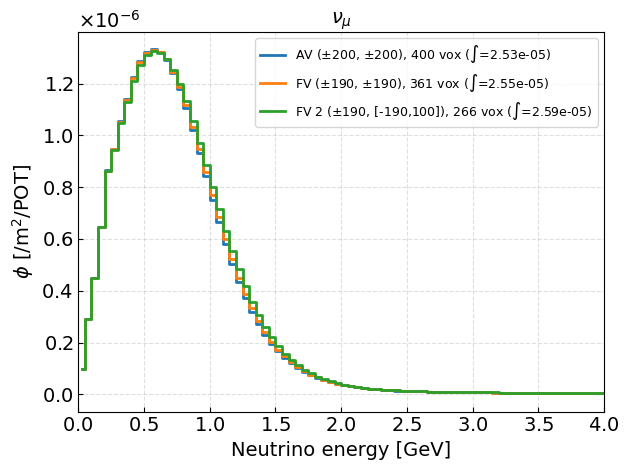

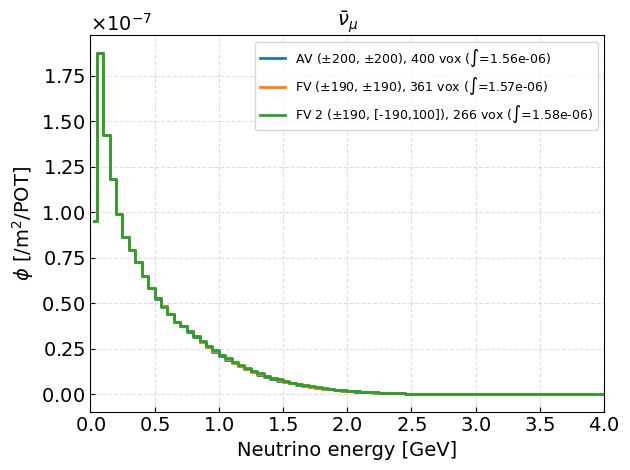

In [8]:
FACE_Z = (11000, 11020)

face_windows = {
    "AV ($\\pm$200, $\\pm$200)":          dict(x_range=(-200, 200), y_range=(-200, 200)),
    "FV ($\\pm$190, $\\pm$190)":       dict(x_range=(-190, 190), y_range=(-190, 190)),
    "FV 2 ($\\pm$190, [-190,100])":    dict(x_range=(-190, 190), y_range=(-190, 100)),
}

face_spectra = {flav: {} for flav in FLAVORS}
for label, win in face_windows.items():
    mask_face = voxel_mask(z_range=FACE_Z, **win)
    for flav in FLAVORS:
        spec, n_vox = flux_for_volume(mask_face, flav)
        face_spectra[flav][label] = (spec, n_vox)

for flav in FLAVORS:
    fig, ax = plt.subplots()
    for label, (spec, n_vox) in face_spectra[flav].items():
        integ = integrated_flux(spec)
        ax.step(bin_centers, spec, where="mid",
                label=f"{label}, {n_vox} vox ($\\int$={integ:.2e})")
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]}")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9, loc="upper right")
    plt.tight_layout()
    plt.show()


## Combined comparison: volume vs faces


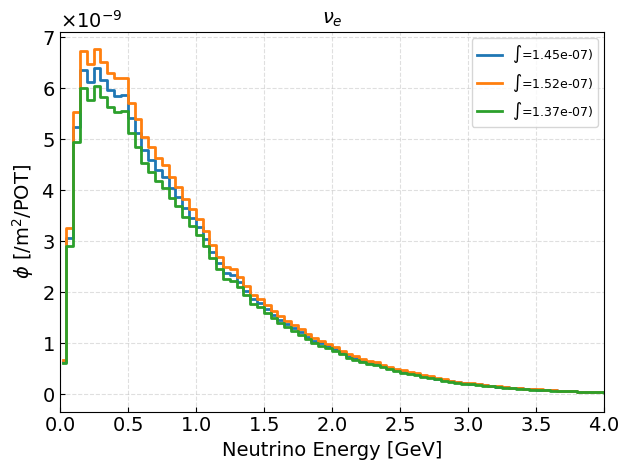

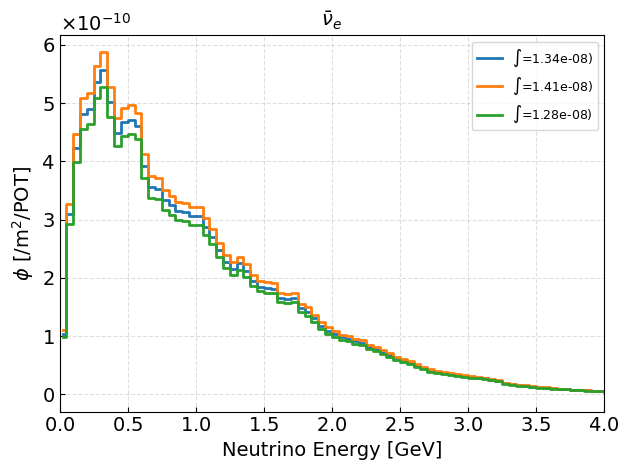

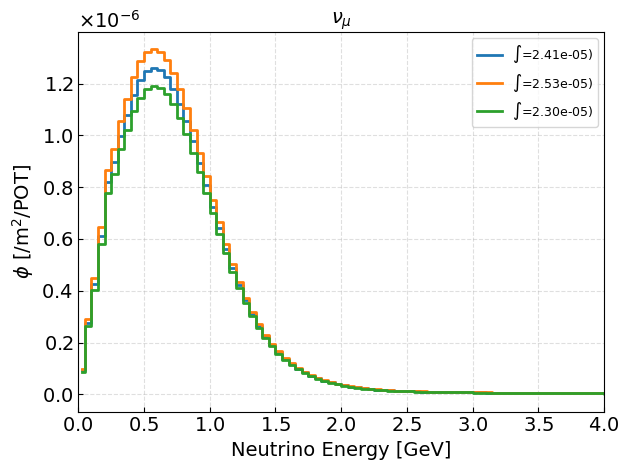

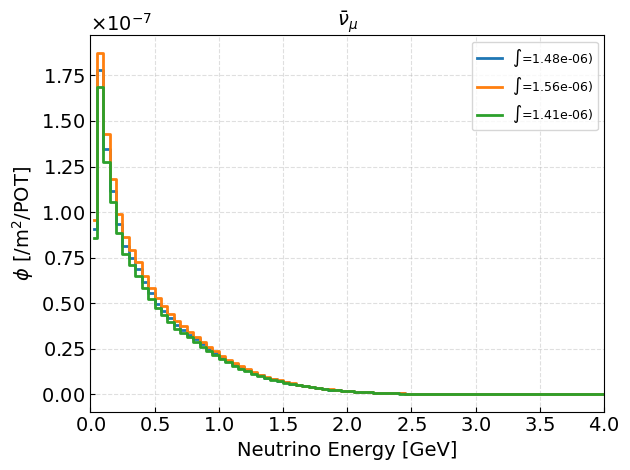

In [9]:
configs = {
    "SBND volume (avg over z)":
        voxel_mask(**SBND_VOLUME),
    "upstream face":
        voxel_mask(z_range=FACE_Z, x_range=(-200, 200), y_range=(-200, 200)),
    "downstream face":
        voxel_mask(z_range=(11480, 11500), x_range=(-200, 200), y_range=(-200, 200)),
}

for flav in FLAVORS:
    fig, ax = plt.subplots()
    for label, mask in configs.items():
        spec, n_vox = flux_for_volume(mask, flav)
        integ = integrated_flux(spec)
        ax.step(bin_centers, spec, where="mid",
                label=f"$\\int$={integ:.2e})")
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino Energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]}")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
